In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from algorithms import globals
import os
import numpy as np
import matplotlib.patheffects as pe

In [2]:
logs_mnist = [
    { "name" : "adagrad", "path": "./networks_mnist/Adagrad/ada_aclosstim_tanh_updt_logs/ada_aclosstim_tanh_updt_records.csv", "run_path": "./networks_mnist/Adagrad/ada_aclosstim_tanh_updt_logs/ada_aclosstim_tanh_updt_run_records.csv"},
    { "name" : "L_BFGS_B", "path": "./networks_mnist/BFGS/bfgs_aclosstim_tanh_updt_logs/bfgs_aclosstim_tanh_updt_records.csv", "run_path": "./networks_mnist/BFGS/bfgs_aclosstim_tanh_updt_logs/bfgs_aclosstim_tanh_updt_run_records.csv"},
    { "name" : "adam", "path": "./networks_mnist/Adam/adam_aclosstim_tanh_updt_logs/adam_aclosstim_tanh_updt_records.csv", "run_path": "./networks_mnist/Adam/adam_aclosstim_tanh_updt_logs/adam_aclosstim_tanh_updt_run_records.csv"},
    { "name" : "cmaes", "path": "./networks_mnist/CMAES/cmaes_aclosstim_tanh_updt_logs/cmaes_aclosstim_tanh_updt_records.csv", "run_path": "./networks_mnist/CMAES/cmaes_aclosstim_tanh_updt_logs/cmaes_aclosstim_tanh_updt_run_records.csv"},
    { "name" : "nl_shade", "path": "./networks_mnist/NLShade/nl_aclosstim_tanh_updt_logs/nl_aclosstim_tanh_updt_records.csv", "run_path": "./networks_mnist/NLShade/nl_aclosstim_tanh_updt_logs/nl_aclosstim_tanh_updt_run_records.csv"},

]

In [3]:
logs_iris = [
    { "name" : "adagrad", "path": "./networks_iris/Adagrad/ada_net_aclosstim_tanh_logs/ada_net_aclosstim_tanh_records.csv", "run_path": "./networks_iris/Adagrad/ada_net_aclosstim_tanh_logs/ada_net_aclosstim_tanh_run_records.csv"},
    { "name" : "L_BFGS_B", "path": "./networks_iris/BFGS/bfgs_net_aclosstim_tanh_logs/bfgs_net_aclosstim_tanh_records.csv", "run_path": "./networks_iris/BFGS/bfgs_net_aclosstim_tanh_logs/bfgs_net_aclosstim_tanh_run_records.csv"},

    { "name" : "adam", "path": "./networks_iris/Adam/adam_net_aclosstim_tanh_logs/adam_net_aclosstim_tanh_records.csv", "run_path": "./networks_iris/Adam/adam_net_aclosstim_tanh_logs/adam_net_aclosstim_tanh_run_records.csv"},
    { "name" : "cmaes", "path": "./networks_iris/CMAES/cmaes_net_aclosstim_tanh_logs/cmaes_net_aclosstim_tanh_records.csv", "run_path": "./networks_iris/CMAES/cmaes_net_aclosstim_tanh_logs/cmaes_net_aclosstim_tanh_run_records.csv"},
    { "name" : "nl_shade", "path": "./networks_iris/NLShade/nl_net_aclosstim_tanh_logs/nl_net_aclosstim_tanh_records.csv", "run_path": "./networks_iris/NLShade/nl_net_aclosstim_tanh_logs/nl_net_aclosstim_tanh_run_records.csv"},

]

In [4]:
logs_cec = [
    { "name" : "adagrad", "path": "./Adagrad/adagrad_curr_updt_logs/adagrad_curr_updt_records_", "run_path": "./Adagrad/adagrad_curr_updt_logs/adagrad_curr_updt_run_records_"},
    { "name" : "L_BFGS_B", "path": "./BFGS/BFGS_curr_updt_logs/BFGS_curr_updt_records_", "run_path": "./BFGS/BFGS_curr_updt_logs/BFGS_curr_updt_run_records_"},
    { "name" : "adam", "path": "./Adam/adam_curr_updt_logs/adam_curr_updt_records_", "run_path": "./Adam/adam_curr_updt_logs/adam_curr_updt_run_records_"},
    { "name" : "cmaes", "path": "./cmaes/cmaes_curr_updt_logs/cmaes_curr_updt_records_", "run_path": "./cmaes/cmaes_curr_updt_logs/cmaes_curr_updt_run_records_"},
    { "name" : "nl_shade", "path": "./nl_shade/nl_shade_curr_updt_logs/nl_shade_curr_updt_records_", "run_path": "./nl_shade/nl_shade_curr_updt_logs/nl_shade_curr_updt_run_records_"},
]

In [5]:

def get_net_records(path):
    records = []

    if not os.path.exists(path):
        records = None
    elif path.__contains__("run_records"):
        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                help = row["error"].strip("()[]").split(",")
                row["acc"] = (1-float(help[0]))
                row["error"] = help[1]
                row["time"] = help[2]
                converted_row = {
                    key: (float(value) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)

    else:

        with open(path, mode='r', newline='') as file:
            reader = csv.DictReader(file)
            for row in reader:
                converted_row = {
                    key: (float(value) if key != 'algorithm' else value)
                    for key, value in row.items()
                }
                records.append(converted_row)
    return records



In [6]:


def get_records(path):
    if not os.path.exists(path):
        return None

    records = []

    with open(path, mode='r', newline='') as file:
        reader = csv.DictReader(file)

        for row in reader:
            converted_row = {}

            for key, value in row.items():
                
                if key == 'function':
                    converted_row[key] = value

                elif key == 'dimensions':
                    converted_row['dim'] = value

                elif key == 'error':
                    vals = [
                        float(v.strip())
                        for v in value.strip('[]').split(',')
                    ]

                    error = vals[0]
                    time = vals[-1]

                    if error == 0:
                        error = 1e-8

                    converted_row['error'] = error
                    converted_row['time'] = time

                else:
                    val = float(value.strip('[]'))

                    if val == 0:
                        val = 1e-8

                    converted_row[key] = val

            records.append(converted_row)
    return records

In [7]:
offset = 0.005
def compare():
    checkpoints = globals.def_checkpoints

    omega_times = {} # alg: {dim:(mean, std), } cec_10, cec_30, iris, cec_50, mnist

        # fig, axs = plt.subplots(3, 3, figsize=(20, 18))
        # axs = axs.flatten()
        # plot_idx = 0

        ## mean + std z 
        #### shifted ECDF
        # ecdf checkpoint times

########### CEC

    algs_run_records = {}

    for curr_f in globals.CEC2013:
        for algorithm in logs_cec:
            if algs_run_records.get(algorithm['name']) is None:
                algs_run_records[algorithm['name']] = get_records(f"{algorithm['run_path']}{curr_f['shortname']}.csv")
            else:
                algs_run_records[algorithm['name']] = get_records(f"{algorithm['run_path']}{curr_f['shortname']}.csv") + algs_run_records.get(algorithm['name'])


    for algorithm_name, run_records in algs_run_records.items():

        if not run_records:
            continue

        omega_times[algorithm_name] = {}
        for dim in globals.def_dimensions:

            times = [
                r['time']
                for r in run_records
                if r['checkpoint'] == 1.0
                if r['dimension'] == dim
                # and r['time'] is not None
                # and not np.isnan(r['time'])
            ]
            omega_times[algorithm_name][dim] = (np.mean(times), np.std(times))
    
###################### IRIS
    algs_run_records = {}

    for algorithm in logs_iris:
        algs_run_records[algorithm['name']] = get_net_records(f"{algorithm['run_path']}")
            
    for algorithm_name, run_records in algs_run_records.items():
        times = [
            r['time']
            for r in run_records
            if r['checkpoint'] == 1.0
            # and r['time'] is not None
            # and not np.isnan(r['time'])
        ]
        omega_times[algorithm_name][39] = (np.mean(times), np.std(times))

        
###################### MNIST
    algs_run_records = {}

    for algorithm in logs_mnist:
        algs_run_records[algorithm['name']] = get_net_records(f"{algorithm['run_path']}")
            
    for algorithm_name, run_records in algs_run_records.items():
        times = [
            r['time']
            for r in run_records
            if r['checkpoint'] == 1.0
            # and r['time'] is not None
            # and not np.isnan(r['time'])
        ]
        omega_times[algorithm_name][3658] = (np.mean(times), np.std(times))

        # print(" -----  ", algorithm_name)
        # print(times)
        # print(len(times))
    # print(omega_times["adagrad"].keys())




############# plotting

    fig, axs = plt.subplots(1, 2, figsize=(20, 10))

    i = -2
    for algo in omega_times.keys():
        means = []
        stds = []
        # if algo in ['adagrad', 'adam', 'L_BFGS_B']:
        #     ax = axs[1]
        # else:
        #     ax = axs[0]

        Y = list(omega_times[algo].keys())
        for dim in omega_times[algo].keys():
            means.append(omega_times[algo][dim][0])
            stds.append(omega_times[algo][dim][1])
    
        Y, means, stds = zip(*sorted(zip(Y, means, stds)))


        Y_cec = []
        mean_cec = []
        std_cec = []
        Y_net = []
        mean_net = []
        std_net = []

        for y in range(len(Y)):
            if Y[y] in globals.def_dimensions:
                Y_cec.append(Y[y])
                mean_cec.append(means[y])
                std_cec.append(stds[y])
            else:
                Y_net.append(Y[y])
                mean_net.append(means[y])
                std_net.append(stds[y])

        help = np.array(Y_cec, dtype=float)
        axs[0].plot(help + (offset*20*i), mean_cec, label=f"{algo}_cec", marker='o')
        axs[0].fill_between(help + (offset*20*i),
                        np.array(mean_cec) - np.array(std_cec),
                        np.array(mean_cec) + np.array(std_cec),
                        alpha=0.2)
        
        help = np.array(Y_net, dtype=float)
        axs[1].plot(help * (1+(offset*i)), mean_net, label=f"{algo}_net", marker='o')
        axs[1].fill_between(help + offset,
                        np.array(mean_net) - np.array(std_net),
                        np.array(mean_net) + np.array(std_net),
                        alpha=0.2)

        i += 1

    # axs[0].set_xscale('log')
    axs[0].set_xlabel('dimensions')
    axs[0].set_ylabel('time')
    axs[0].set_title('cec times')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].set_xscale('log')
    axs[1].set_xlabel('dimensions')
    axs[1].set_ylabel('time')
    axs[1].set_title('net times')
    axs[1].legend()
    axs[1].grid(True)

    plt.show()

    # ax.plot(
    #     omega_times["adagrad"][],
    #     y[algorithm_name],
    #     label=algorithm_name,
    #     marker='o'
    # )
    # i += 1
    # ax.set_xlabel('Average runtime (seconds)')
    # ax.set_ylabel('Fraction of thresholds reached')
    # ax.set_title("ECDF vs runtime")

    # ax.set_xscale('log')
    # ax.set_ylim([0, 1.05])
    # ax.grid(True)
    # ax.legend()


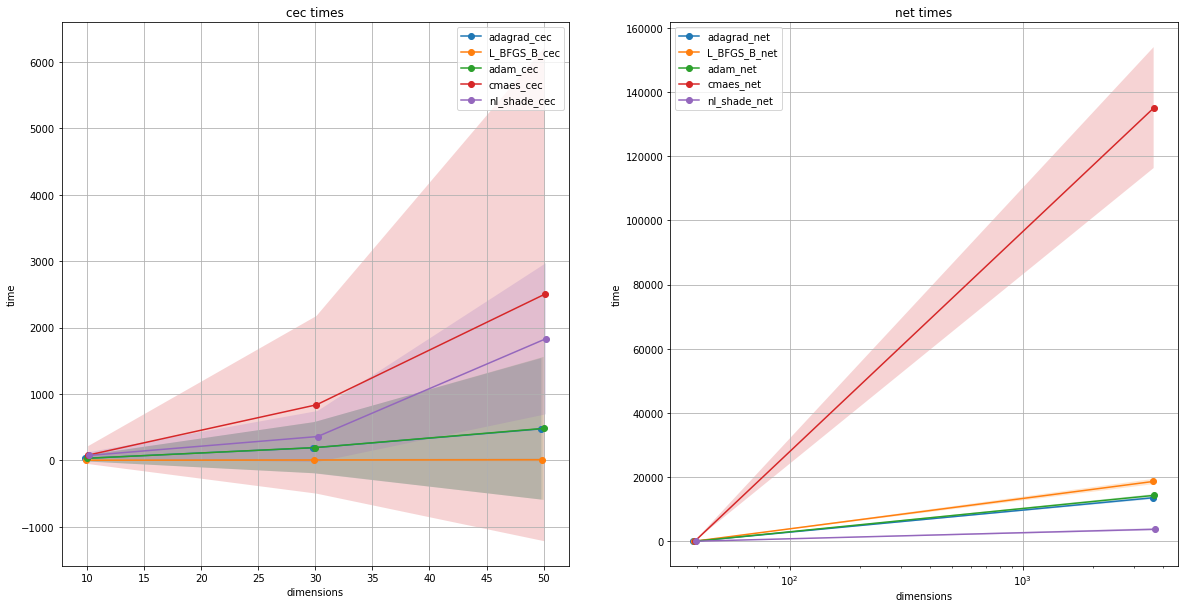

In [8]:
compare()